In [1]:
from process_impl import config

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def plot_evaluation_metrics(evals_path):
    print(evals_path)
    data = np.load(evals_path)
    
    if 'timesteps' not in data or 'results' not in data:
        raise ValueError("O arquivo .npz deve conter 'timesteps' e 'results' (como salvo pelo EvalCallback)")

    timesteps = data['timesteps']
    results = data['results']  # shape: (n_evals, n_eval_episodes)

    # Média e desvio-padrão das recompensas
    mean_rewards = results.mean(axis=1)
    std_rewards = results.std(axis=1)

    # Encontrar índice onde o best model foi salvo
    best_idx = np.argmax(mean_rewards)
    best_mean_reward = mean_rewards[best_idx]
    best_timestep = timesteps[best_idx]
    best_std = std_rewards[best_idx]

    # Gráfico 1 – Curva de convergência com destaque no melhor modelo
    plt.figure(figsize=(8, 4))
    plt.plot(timesteps, mean_rewards, '.-', label='Mean Reward')
    plt.fill_between(timesteps, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.3, label='±1 std')
    plt.scatter([best_timestep], [best_mean_reward], color='red', zorder=5, label='Best Model')
    plt.annotate(
        f'Mean: {best_mean_reward:.2f}\nStd: {best_std:.2f}',
        xy=(best_timestep, best_mean_reward),
        xytext=(best_timestep, best_mean_reward + 0.05),
        textcoords='data',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='red', facecolor='white'),
        arrowprops=dict(arrowstyle='->', color='red')
    )
    plt.xlabel("Timesteps")
    plt.ylabel("Mean Reward")
    plt.title("Convergência do Treinamento (Recompensa Média por Avaliação)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Gráfico 2 – Histograma da MELHOR avaliação
    plt.figure(figsize=(6, 4))
    plt.hist(results[best_idx], bins=10, alpha=0.7, color='orange')
    plt.title(f"Distribuição das Recompensas na Melhor Avaliação (t={best_timestep})")
    plt.xlabel("Reward")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Gráfico 3 – Boxplot com destaque na melhor avaliação
    plt.figure(figsize=(10, 4))
    plt.boxplot(results.T, positions=timesteps, widths=timesteps[1] - timesteps[0])
    plt.axvline(x=best_timestep, color='red', linestyle='--', label='Best Model')
    plt.title("Boxplot das Recompensas por Avaliação")
    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

   
    # Supondo que você já tenha essas variáveis definidas:
    # timesteps: vetor 1D com os steps (ex: np.arange(len(mean_rewards)))
    # mean_rewards: vetor 1D com as médias
    # std_rewards: vetor 1D com os desvios padrão
    
    # Área sombreada do desvio padrão
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=np.concatenate([timesteps, timesteps[::-1]])*3,
        y=np.concatenate([mean_rewards + std_rewards, (mean_rewards - std_rewards)[::-1]]),
        fill='toself',
        fillcolor='lightgray',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name='Reward Standard Deviation in Evaluation Simulations'
    ))
    
    # Linha da média
    fig.add_trace(go.Scatter(
        x=timesteps*3,
        y=mean_rewards,
        mode='lines',
        name='Mean Reward in Evaluation Simulations',
        line=dict(color='black', width=5)
    ))
        
    fig.update_layout(
        xaxis=dict(
            title=dict(
                text='Total learning steps',
                font=dict(size=20)
            ),
            tickfont=dict(size=16)
        ),
        yaxis=dict(
            title=dict(
                text='Sum of Rewards',
                font=dict(size=20)
            ),
            tickfont=dict(size=16)
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.65,
            xanchor="center",
            x=0.5,
            font=dict(size=16)
        ),
        height=400,
        width=800
    )

    
    # Mostrar o gráfico
    fig.show()
    # Salvar como PNG com alta resolução
    fig.write_image("conv.png", format="png", width=800, height=400, scale=6, engine="kaleido")


In [3]:
cd = "C:\\Users\\Douglas\\Desktop\\codigos_mestrado9_aws_ph_forcle\\src\\models_\\best_model_ferm_187_reward_params_2.5_2.5_30.34_-0.11_9.66_-0.87_0.95_5__1_"


C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_187_reward_params_2.5_2.5_30.34_-0.11_9.66_-0.87_0.95_5__0_\evaluations.npz


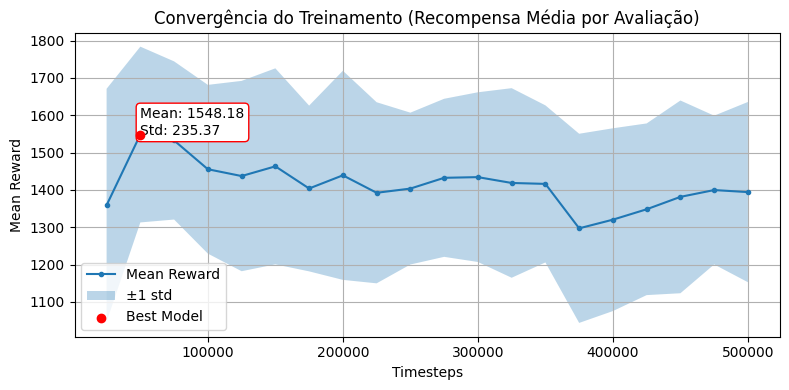

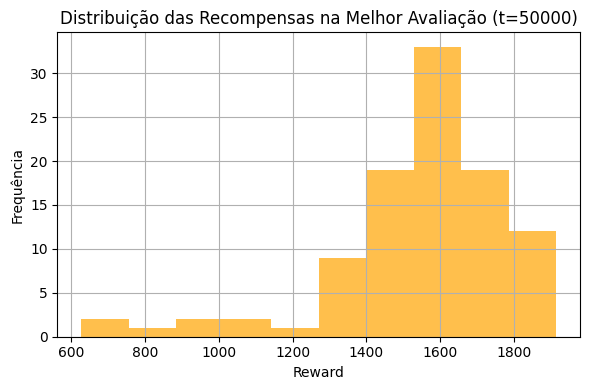

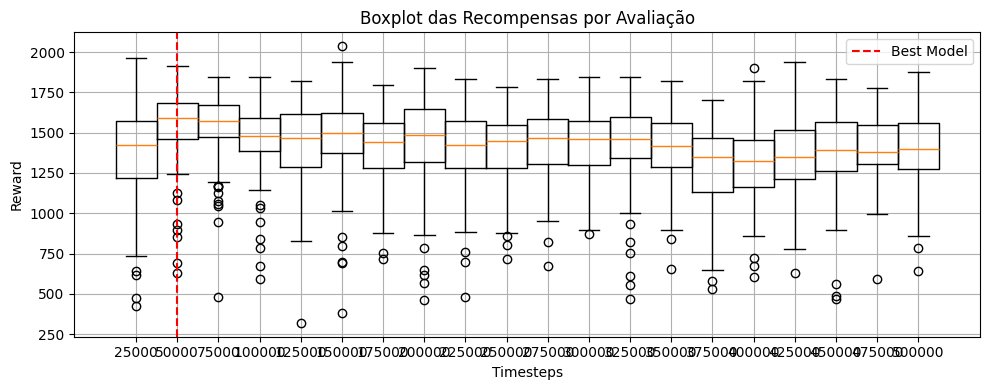

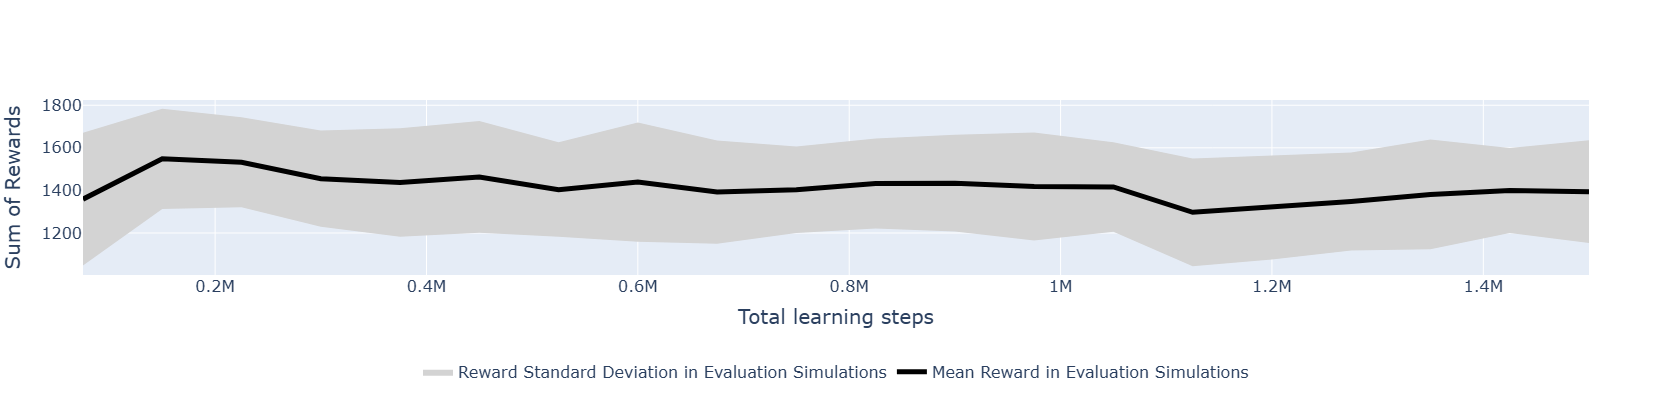

C:\Users\Douglas\AppData\Local\Temp\ipykernel_107512\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_187_reward_params_2.5_2.5_30.34_-0.11_9.66_-0.87_0.95_5__1_\evaluations.npz


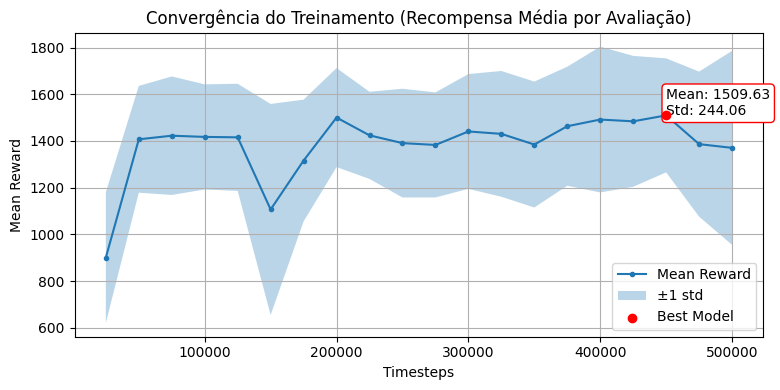

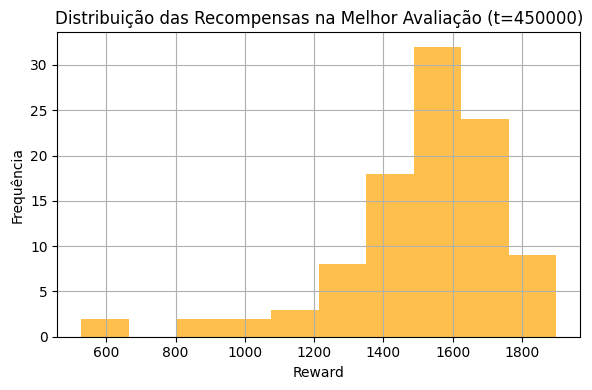

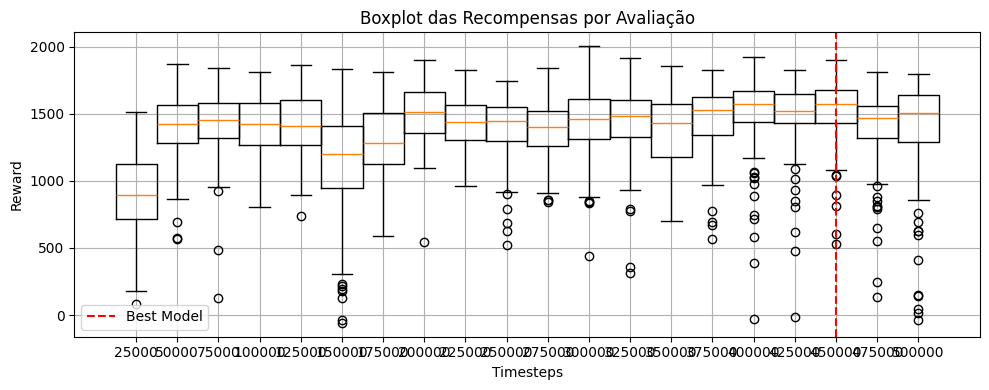

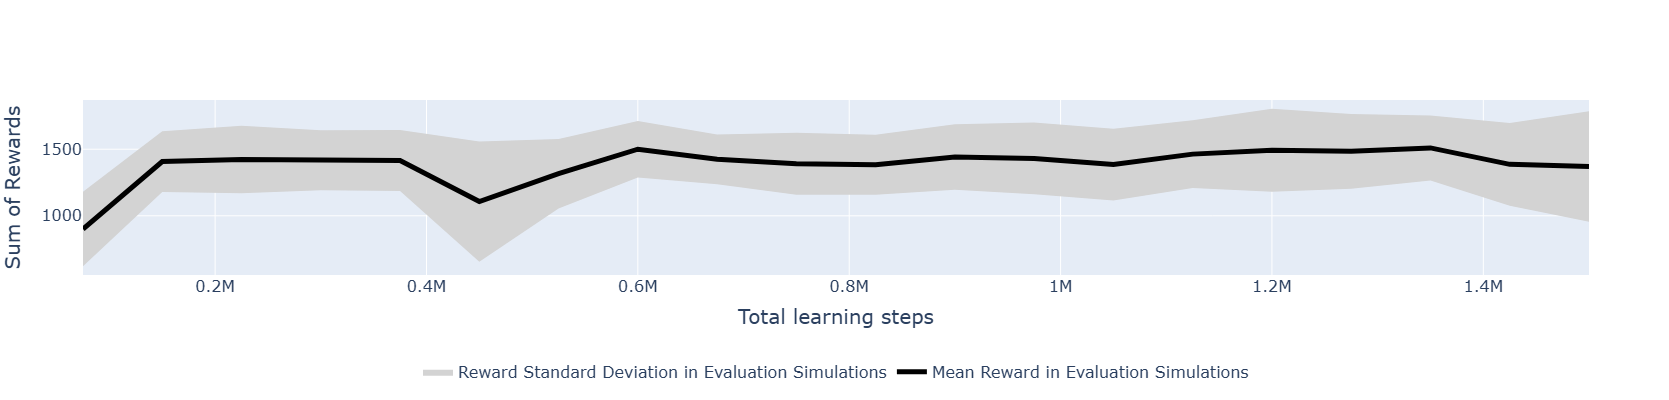

C:\Users\Douglas\AppData\Local\Temp\ipykernel_107512\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_187_reward_params_2.5_2.5_30.34_-0.11_9.66_-0.87_0.95_5__2_\evaluations.npz


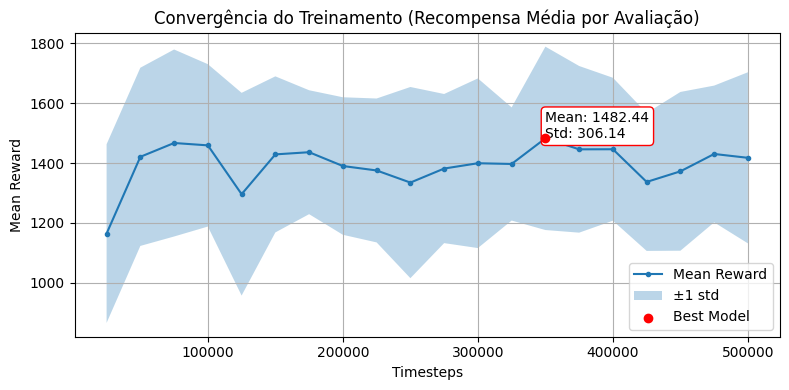

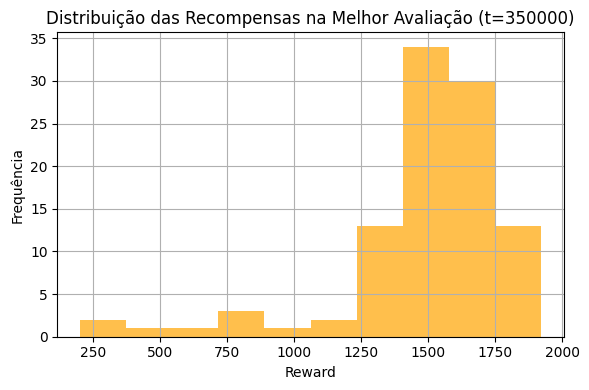

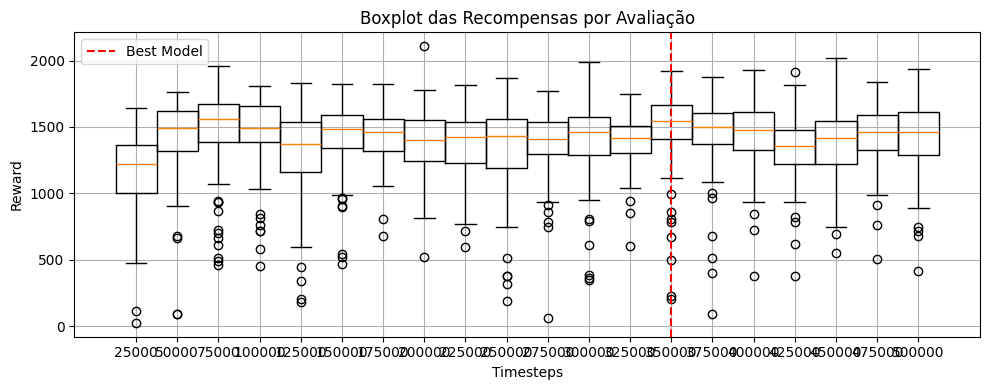

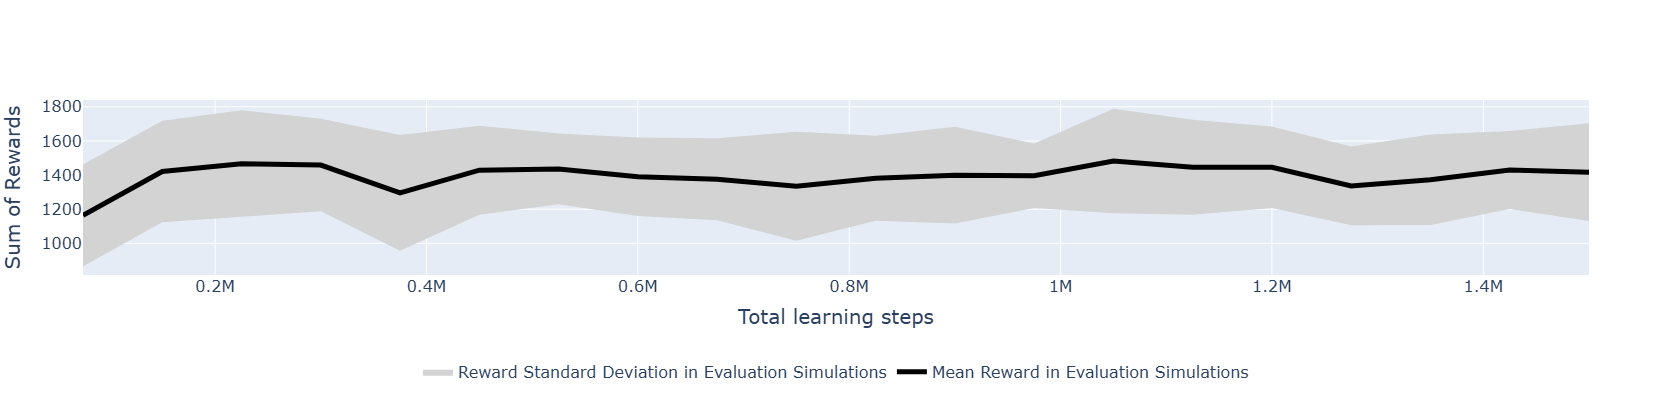

C:\Users\Douglas\AppData\Local\Temp\ipykernel_107512\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




C:\Users\Douglas\Desktop\codigos_mestrado9_aws_ph_forcle\src\models_\best_model_ferm_187_reward_params_2.5_2.5_30.34_-0.11_9.66_-0.87_0.95_5__3_\evaluations.npz


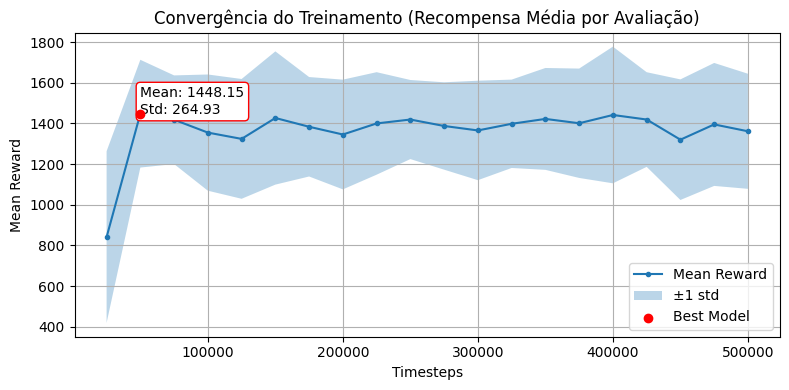

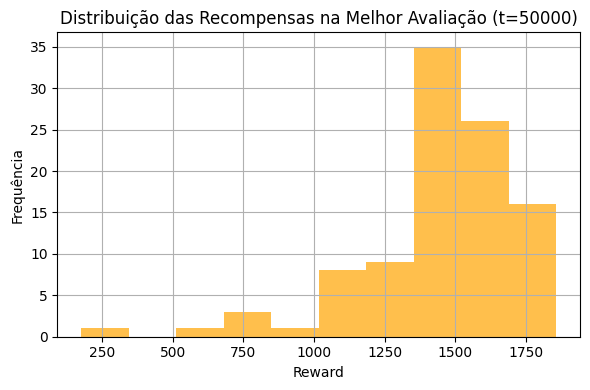

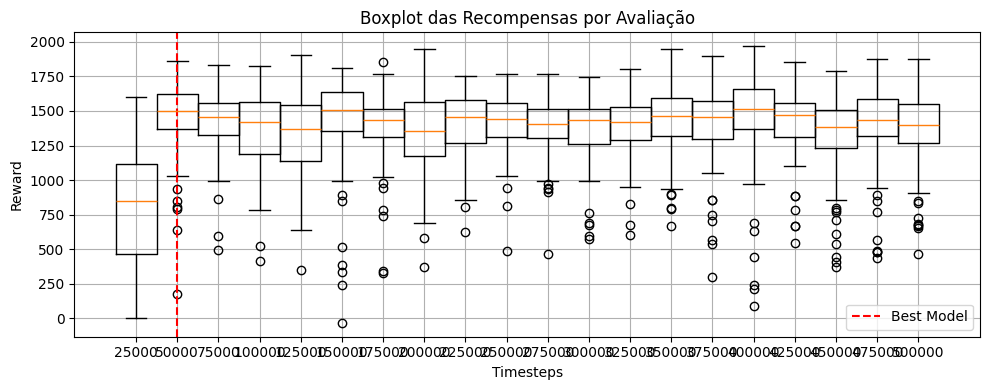

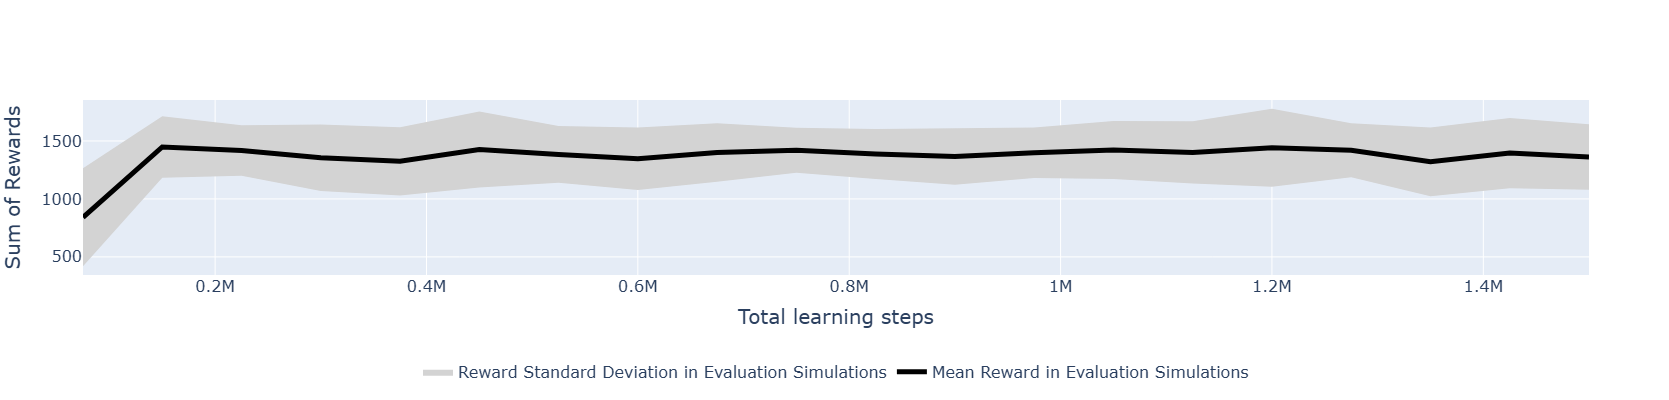

C:\Users\Douglas\AppData\Local\Temp\ipykernel_107512\728759529.py:128: DeprecationWarning:


Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.




In [9]:
plot_evaluation_metrics(cd[:-2]+"0_" + "\\evaluations.npz")
plot_evaluation_metrics(cd[:-2]+"1_" + "\\evaluations.npz")
plot_evaluation_metrics(cd[:-2]+"2_" + "\\evaluations.npz")
plot_evaluation_metrics(cd[:-2]+"3_" + "\\evaluations.npz")


Running evaluation for variable: h1
1.7478235837817193
  → Changing h1 to 8.5
1.5865440630912782
  → Changing h1 to 10.0
1.6782602506875992


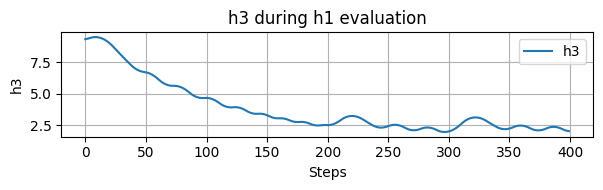

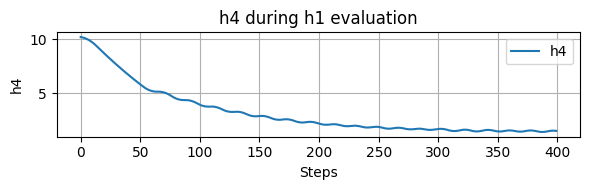

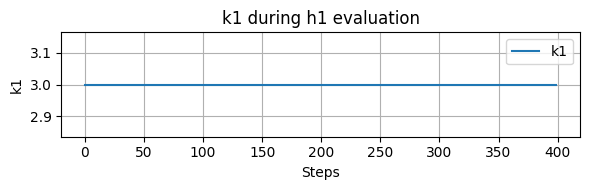

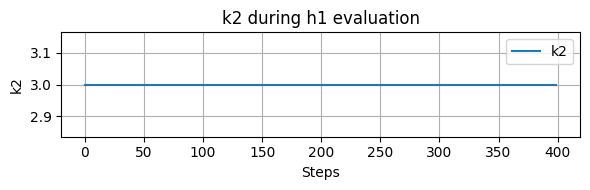

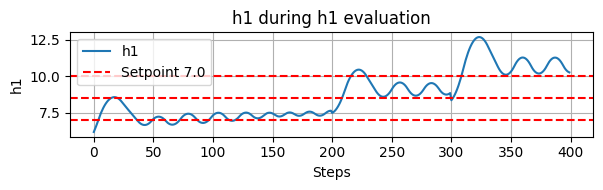

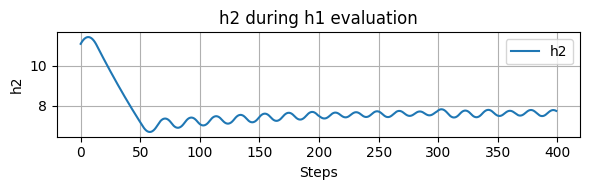

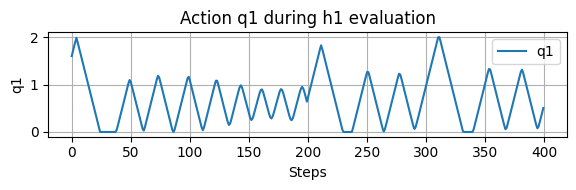

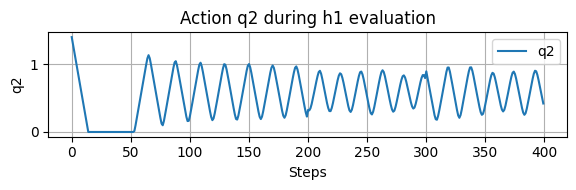

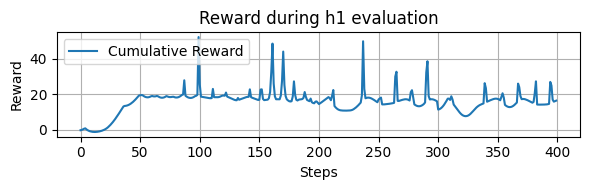


Running evaluation for variable: h2
1.7173282012343407
  → Changing h2 to 8.5
1.8270105415582656
  → Changing h2 to 10.0
1.8559592682123185


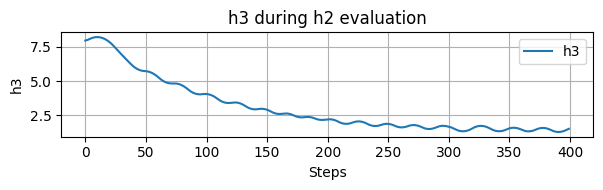

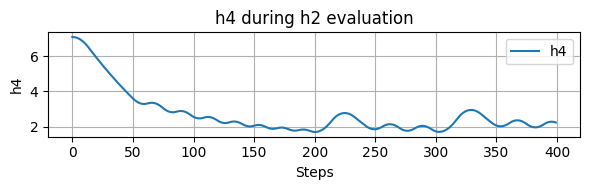

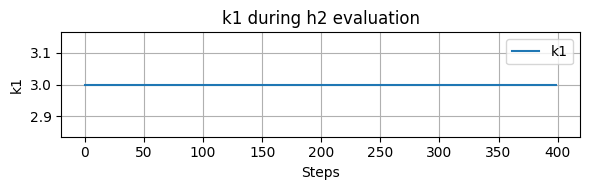

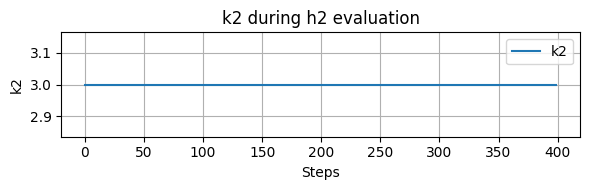

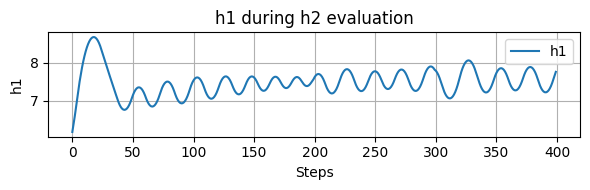

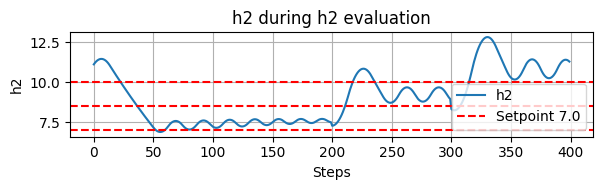

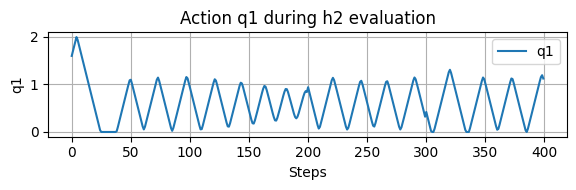

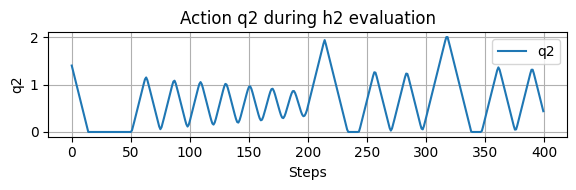

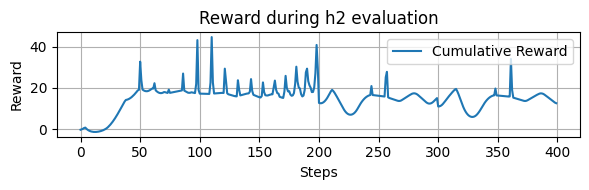


Running evaluation for variable: h3
1.7109690952301024
  → Changing h3 to 9
1.1237319165468216
  → Changing h3 to 12
1.600209856033325


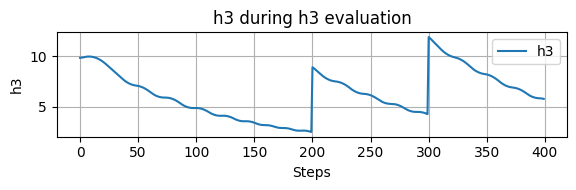

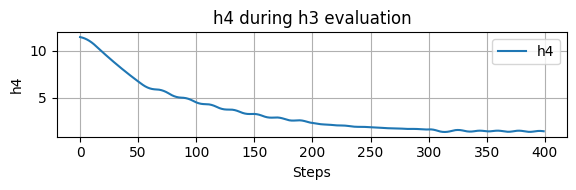

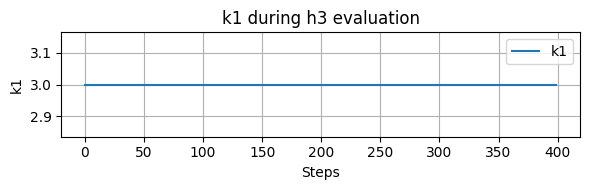

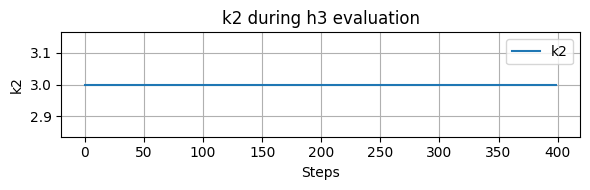

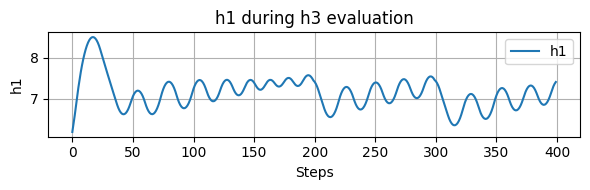

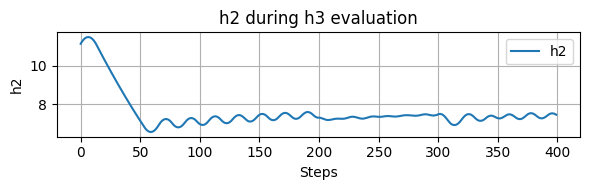

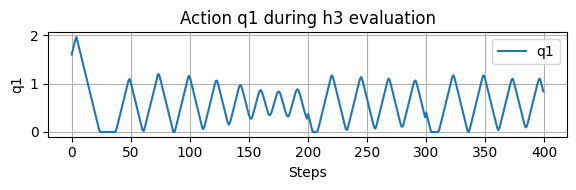

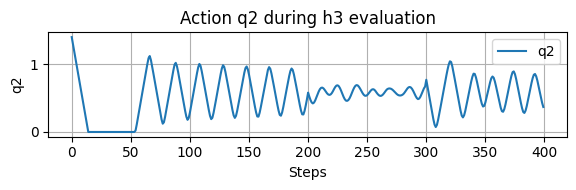

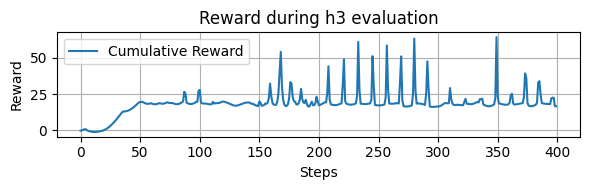


Running evaluation for variable: h4
1.7260294035077095
  → Changing h4 to 9
1.7157579493522643
  → Changing h4 to 12
1.7423026692867278


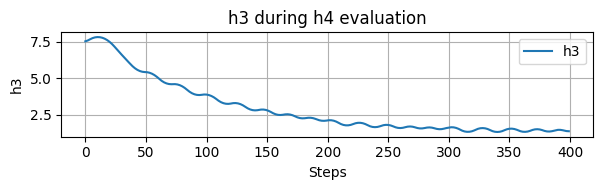

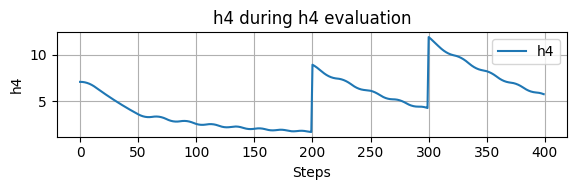

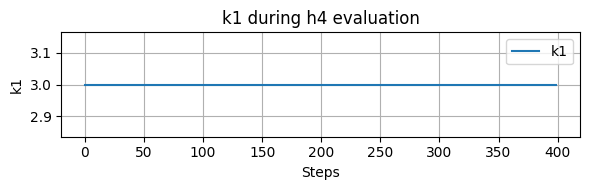

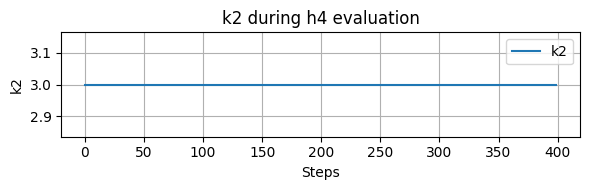

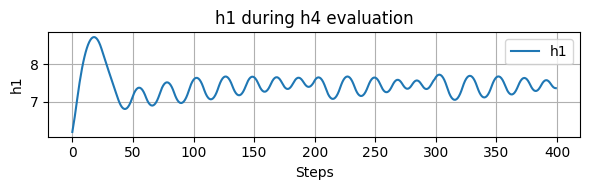

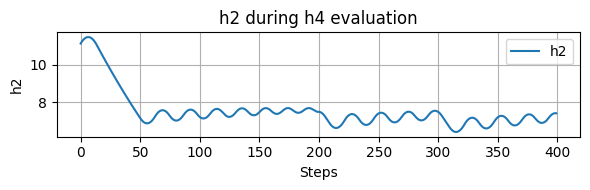

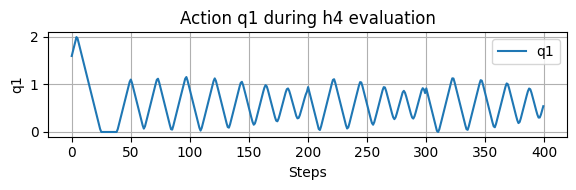

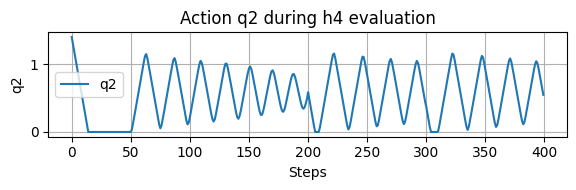

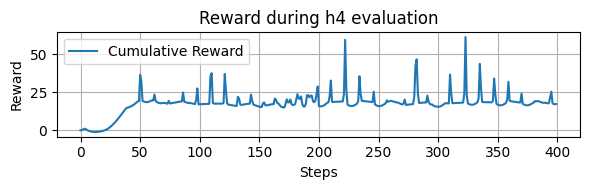


Running evaluation for variable: k1
1.748934336602688
  → Changing k1 to 2
0.6838266628980637
  → Changing k1 to 4
1.2131126344203949


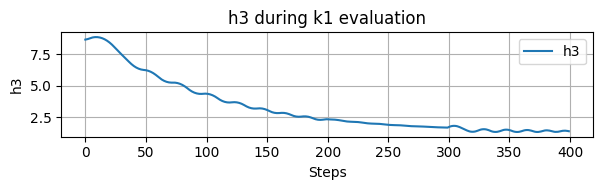

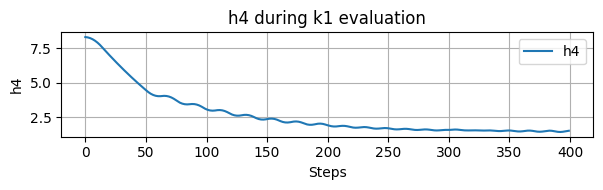

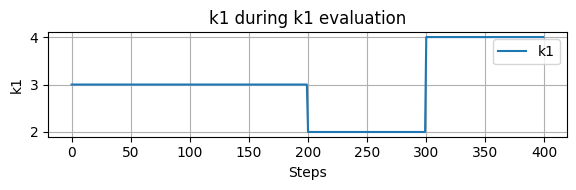

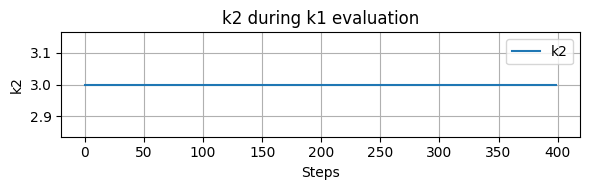

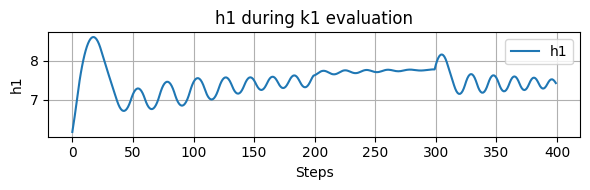

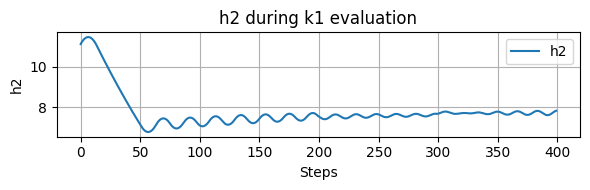

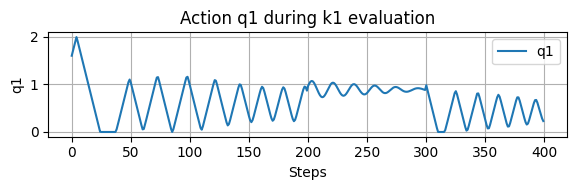

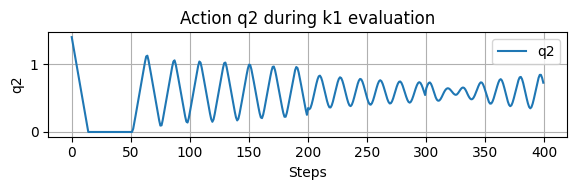

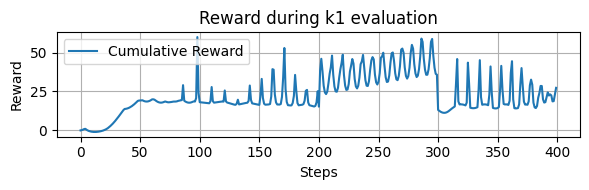


Running evaluation for variable: k2
1.7163820973038673
  → Changing k2 to 2
1.6172995376586914
  → Changing k2 to 4
1.370367817878723


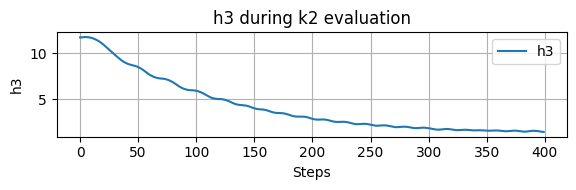

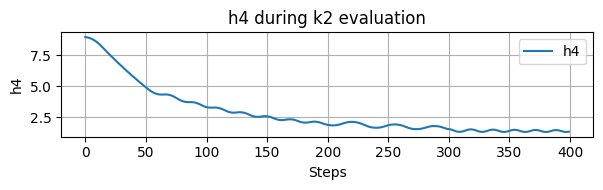

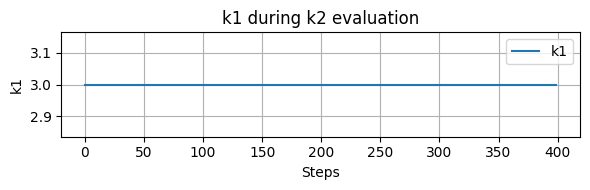

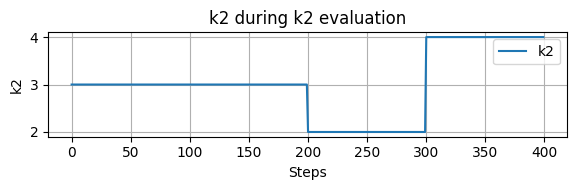

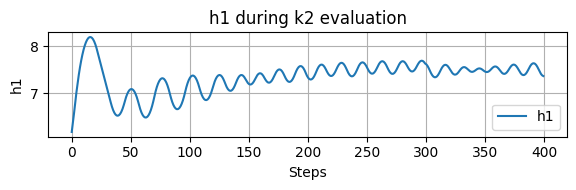

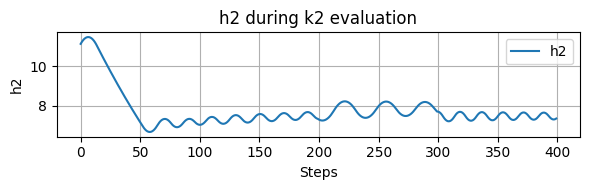

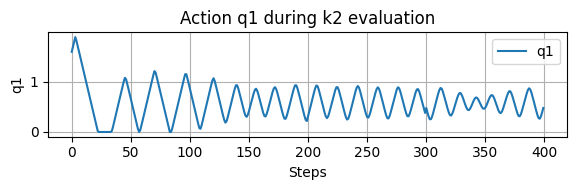

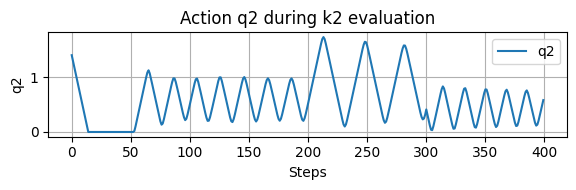

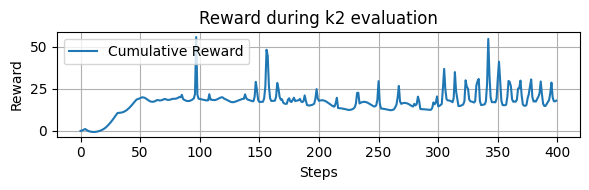

In [4]:
import sys
import os

# Caminho relativo a partir do notebook
sys.path.append(os.path.abspath(os.path.join("..", "..", "src")))

from eval_env_runner import EvaluationEnvRunner
cd = cd[:-2]+"0_"


runner = EvaluationEnvRunner(config, model_dir=cd)
runner.run_evaluations()


In [5]:
a=[1,2,3,2,1,2,23]

In [6]:
l = len(a)
a[int(l/3):] = [10]*int(l/2)

In [7]:
a

[1, 2, 10, 10, 10]

In [8]:
sum([i['IAE_total'] for i in lista_dict])

NameError: name 'lista_dict' is not defined

In [ ]:
[i['IAE_total'] for i in lista_dict]